# Experiment: CyEmbed Archetype Embedding Sweep

Notebook-first training and hyperparameter sweep for CyTOF archetype models.

This notebook supports two decoders:
- `factorized`: `W -> H = WZ -> X_hat = H E^T + b`
- `direct`: `X_hat = W A`

Edit the config cell and run top-to-bottom.


In [2]:
from __future__ import annotations

from pathlib import Path
from itertools import islice
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from CyEmbed.data import extract_matrix, fit_scaler, preprocess_array, split_train_val_indices
from CyEmbed.train import build_sweep_configs, run_sweep
from CyEmbed.utils import collect_software_versions, save_json, set_seed

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)


In [21]:
# === Editable configuration ===
OUTPUT_ROOT = Path("outputs/mcf7_probabilistic_archetype_embedding_sweep")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print(
    f"Using OUTPUT_ROOT: {OUTPUT_ROOT.resolve()} "
    "(existing runs are preserved; completed runs are skipped)"
)

GLOBAL_CFG = {
    "seed": 7,
    "deterministic": True,
    "device": "cpu",  # auto resolves CUDA -> MPS -> CPU
}

DATA_CFG = {
    # Input mode: "adata", "dataframe", or "matrix"
    "input_mode": "adata",

    # Optional path-based loading (set one according to input_mode)
    "adata_path": "/Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/data/MCF7.h5ad",
    "dataframe_path": None,
    "matrix_npy_path": None,

    # AnnData extraction options
    "adata_source": "X",     # "X", "layer", "obsm"
    "adata_layer": None,
    "adata_obsm_key": None,
    "sample_col": None,  # set if per-sample metadata exists
    "cluster_col": "Line",

    # Dataset-specific cleanup/filtering
    "drop_rank_obs_columns": True,
    "filter_nan_label": True,

    # Fallback for dry-runs when no data path/object is supplied
    "allow_synthetic_if_missing": False,
    "synthetic_n_cells": 8000,
    "synthetic_n_markers": 35,
    "synthetic_n_samples": 8,
    "synthetic_n_clusters": 6,
}

PREPROCESS_CFG = {
    "mode": "zscore",  # "none", "zscore", "robust_zscore"
    "balanced_scaling_by_sample": False,
    "balanced_max_per_sample": 2000,
}

SPLIT_CFG = {
    "val_fraction": 0.2,
    "stratify_by": "cluster",  # None, "sample", or "cluster"
    "train_size": 15000,         # force this many train cells if available
}

BASE_TRAIN_CFG = {
    "epochs": 1500,
    "early_stopping": True,
    "patience": 20,
    "min_delta": 0.0,
    "restore_best_weights": True,
    "weight_decay": 1e-5,
    "dropout": 0.0,
    "logit_normalizer": "entmax",
    "entmax_alpha": 1.5,
    "huber_delta": 1.0,
    "separation_mode": "cosine_sq",  # "cosine_mean", "cosine_abs", "cosine_sq", "rbf"
    "balance_mode": "l2_uniform",    # "l2_uniform", "kl_uniform", "neg_entropy"
    "rbf_gamma": 1.0,
    "print_every": 10,
    "progress_sweep": True,
    "skip_existing_runs": True,
    "progress_epoch": True,

    # Probabilistic-model defaults (ignored by deterministic model_type)
    "beta_w": 1e-3,
    "beta_r": 1e-3,
    "residual_dim": 8,
    "logvar_max": 5.0,
    "grad_clip_norm": 5.0,
    "kl_warmup_epochs": 10,
    "prob_eval_mode": "mean",      # "mean", "sample", or "mc"
    "prob_eval_samples": 3,
}

SWEEP_GRID = {
    # Probabilistic variants only for MCF7.
    "model_type": ["probabilistic"],
    "use_residual_latent": [False],
    "decoder_type": ["direct"],

    "K": [4,5, 6,7,8,10,15],
    "d": [8],
    "hidden_dims": [[256, 128]],
    "lr": [1e-3],
    "batch_size": [2048],  # try 1024/512 if you hit OOM
    "recon_loss_type": ["mse"],
    "lambda_entropy": [1e-3],
    "lambda_sep": [1e-3],
    "lambda_balance": [5e-2],
    "tau": [0.7, 1.0],

    # Probabilistic-specific sweep knobs
    "beta_w": [1e-3],
    "beta_r": [1e-3],
    "residual_dim": [8],
    "kl_warmup_epochs": [10],
}

MAX_RUNS = None


Using OUTPUT_ROOT: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/mcf7_probabilistic_archetype_embedding_sweep (existing runs are preserved; completed runs are skipped)


In [22]:
# === Data loading ===
# You can provide data in any of these ways:
# 1) Set DATA_CFG paths above.
# 2) Predefine one of `adata_obj`, `prepared_df`, `prepared_matrix` in the notebook.

set_seed(GLOBAL_CFG["seed"], deterministic=GLOBAL_CFG["deterministic"])

adata_obj = globals().get("adata_obj", None)
prepared_df = globals().get("prepared_df", None)
prepared_matrix = globals().get("prepared_matrix", None)

bundle = None

if DATA_CFG["input_mode"] == "adata":
    adata = adata_obj
    if adata is None and DATA_CFG["adata_path"] is not None:
        import anndata as ad
        adata = ad.read_h5ad(DATA_CFG["adata_path"])

    if adata is not None:
        obs_cols = pd.Index(adata.obs.columns)
        label_like_cols = [
            c for c in obs_cols
            if any(tok in str(c).lower() for tok in ["label", "cluster", "celltype", "cell_type"])
        ]
        print(f"Detected label-like obs columns: {label_like_cols}")

        if DATA_CFG.get("drop_rank_obs_columns", False):
            rank_cols = [c for c in obs_cols if str(c).lower().endswith("_rank")]
            if rank_cols:
                adata.obs = adata.obs.drop(columns=rank_cols)
                print(f"Dropped rank obs columns: n={len(rank_cols)}")

        resolved_cluster_col = DATA_CFG.get("cluster_col")
        if resolved_cluster_col is None and len(label_like_cols) > 0:
            resolved_cluster_col = label_like_cols[0]
        print(f"Using cluster column: {resolved_cluster_col}")

        bundle = extract_matrix(
            adata=adata,
            source=DATA_CFG["adata_source"],
            layer=DATA_CFG["adata_layer"],
            obsm_key=DATA_CFG["adata_obsm_key"],
            sample_col=DATA_CFG["sample_col"],
            cluster_col=resolved_cluster_col,
        )

        if DATA_CFG.get("filter_nan_label", False):
            if bundle.cluster_ids is None:
                print("filter_nan_label=True but no cluster labels are available; skipping filter.")
            else:
                label_series = pd.Series(bundle.cluster_ids)
                keep_mask = (~label_series.isna()).to_numpy()
                removed = int((~keep_mask).sum())
                if removed > 0:
                    bundle.X = bundle.X[keep_mask]
                    bundle.cell_ids = [cid for cid, keep in zip(bundle.cell_ids, keep_mask) if keep]
                    if bundle.sample_ids is not None:
                        bundle.sample_ids = bundle.sample_ids[keep_mask]
                    if bundle.cluster_ids is not None:
                        bundle.cluster_ids = bundle.cluster_ids[keep_mask]
                print(f"Filtered NaN labels: removed={removed}, kept={bundle.X.shape[0]}")

elif DATA_CFG["input_mode"] == "dataframe":
    df = prepared_df
    if df is None and DATA_CFG["dataframe_path"] is not None:
        df = pd.read_csv(DATA_CFG["dataframe_path"], index_col=0)
    if df is not None:
        bundle = extract_matrix(dataframe=df)

elif DATA_CFG["input_mode"] == "matrix":
    matrix = prepared_matrix
    if matrix is None and DATA_CFG["matrix_npy_path"] is not None:
        matrix = np.load(DATA_CFG["matrix_npy_path"])
    if matrix is not None:
        bundle = extract_matrix(matrix=matrix)

else:
    raise ValueError("DATA_CFG['input_mode'] must be one of: adata/dataframe/matrix")

if bundle is None:
    if not DATA_CFG["allow_synthetic_if_missing"]:
        raise ValueError("No input data found. Provide AnnData/DataFrame/matrix in config.")

    print("No input data supplied. Generating synthetic CyTOF-like matrix for dry-run.")
    n_cells = DATA_CFG["synthetic_n_cells"]
    n_markers = DATA_CFG["synthetic_n_markers"]
    n_samples = DATA_CFG["synthetic_n_samples"]
    n_clusters = DATA_CFG["synthetic_n_clusters"]

    rng = np.random.default_rng(GLOBAL_CFG["seed"])
    z = rng.normal(size=(n_cells, 6)).astype(np.float32)
    loadings = rng.normal(size=(6, n_markers)).astype(np.float32)
    x = z @ loadings + 0.2 * rng.normal(size=(n_cells, n_markers)).astype(np.float32)

    sample_ids = np.array([f"sample_{i}" for i in rng.integers(0, n_samples, size=n_cells)])
    cluster_ids = np.array([f"cluster_{i}" for i in rng.integers(0, n_clusters, size=n_cells)])

    bundle = extract_matrix(
        matrix=x,
        marker_names=[f"marker_{i}" for i in range(n_markers)],
        cell_ids=[f"cell_{i}" for i in range(n_cells)],
        sample_ids=sample_ids,
        cluster_ids=cluster_ids,
    )

print(f"Loaded X shape: {bundle.X.shape}")
print(f"Sample metadata present: {bundle.sample_ids is not None}")
print(f"Cluster metadata present: {bundle.cluster_ids is not None}")


Detected label-like obs columns: []
Using cluster column: Line
Filtered NaN labels: removed=0, kept=20505
Loaded X shape: (20505, 32)
Sample metadata present: False
Cluster metadata present: True


In [23]:
# === Preprocess and split ===
fit_sample_ids = bundle.sample_ids if PREPROCESS_CFG["balanced_scaling_by_sample"] else None
balanced_max = PREPROCESS_CFG["balanced_max_per_sample"] if PREPROCESS_CFG["balanced_scaling_by_sample"] else None

scaler, scaler_fit_idx = fit_scaler(
    bundle.X,
    mode=PREPROCESS_CFG["mode"],
    sample_ids=fit_sample_ids,
    balanced_max_per_sample=balanced_max,
    random_state=GLOBAL_CFG["seed"],
)
X_proc = preprocess_array(bundle.X, scaler)

if SPLIT_CFG["stratify_by"] == "sample" and bundle.sample_ids is not None:
    stratify_labels = bundle.sample_ids
elif SPLIT_CFG["stratify_by"] == "cluster" and bundle.cluster_ids is not None:
    stratify_labels = bundle.cluster_ids
else:
    stratify_labels = None

train_idx, val_idx = split_train_val_indices(
    n_cells=X_proc.shape[0],
    val_fraction=SPLIT_CFG["val_fraction"],
    seed=GLOBAL_CFG["seed"],
    stratify_labels=stratify_labels,
)

target_train = SPLIT_CFG.get("train_size")
if target_train is not None:
    target_train = int(target_train)
    if len(train_idx) > target_train:
        rng = np.random.default_rng(GLOBAL_CFG["seed"])
        train_idx = np.sort(rng.choice(train_idx, size=target_train, replace=False))
    elif len(train_idx) < target_train:
        print(f"Requested train_size={target_train}, but only {len(train_idx)} train cells are available.")

print(f"Scaler mode: {scaler.mode}")
print(f"Scaler fit cells: {len(scaler_fit_idx)}")
print(f"Train cells: {len(train_idx)} | Val cells: {len(val_idx)}")


Scaler mode: zscore
Scaler fit cells: 20505
Train cells: 15000 | Val cells: 4101


In [24]:
# === Build sweep and train ===
sweep_configs = build_sweep_configs(SWEEP_GRID)

# Remove deterministic+residual duplicates since residual applies only to probabilistic model.
filtered_configs = []
for cfg in sweep_configs:
    if cfg.get("model_type", "deterministic") == "deterministic" and bool(cfg.get("use_residual_latent", False)):
        continue
    filtered_configs.append(cfg)
sweep_configs = filtered_configs

if MAX_RUNS is not None:
    sweep_configs = sweep_configs[: int(MAX_RUNS)]

print(f"Total sweep runs: {len(sweep_configs)}")

notebook_config = {
    "global": GLOBAL_CFG,
    "data": DATA_CFG,
    "preprocess": PREPROCESS_CFG,
    "split": SPLIT_CFG,
    "base_train": BASE_TRAIN_CFG,
    "sweep_grid": SWEEP_GRID,
    "software_versions": collect_software_versions(),
    "scaler": scaler.to_dict(),
}
save_json(OUTPUT_ROOT / "notebook_config.json", notebook_config)

summary_df = run_sweep(
    x=X_proc,
    marker_names=bundle.marker_names,
    cell_ids=bundle.cell_ids,
    output_root=OUTPUT_ROOT,
    base_config={**GLOBAL_CFG, **BASE_TRAIN_CFG},
    sweep_configs=sweep_configs,
    train_idx=train_idx,
    val_idx=val_idx,
    sample_ids=bundle.sample_ids,
    cluster_ids=bundle.cluster_ids,
    scaler_state=scaler.to_dict(),
)

summary_df.to_csv(OUTPUT_ROOT / "sweep_summary_sorted.csv", index=False)
summary_df.head(20)


Total sweep runs: 14


Sweep:   0%|          | 0/14 [00:00<?, ?it/s]

[run_probabilistic_5ca9190b1c] Using device: cpu


run_probabilistic_5ca9190b1c epochs:   0%|          | 0/1500 [00:00<?, ?it/s]

[run_probabilistic_5ca9190b1c] Early stopping at epoch 1455 (patience=20, best_epoch=1435, best_val_recon=0.45409)
[run_probabilistic_d2b759aab4] Using device: cpu


...

[run_probabilistic_135aca2424] Using device: cpu


run_probabilistic_135aca2424 epochs:   0%|          | 0/1500 [00:00<?, ?it/s]

[run_probabilistic_33e32ac004] Using device: cpu


run_probabilistic_33e32ac004 epochs:   0%|          | 0/1500 [00:00<?, ?it/s]

,run_id,run_dir,model_type,decoder_type,logit_normalizer,entmax_alpha,use_residual_latent,beta_w,beta_r,residual_dim,K,d,hidden_dims,lr,batch_size,recon_loss_type,lambda_entropy,lambda_sep,lambda_balance,tau,patience,best_epoch,stopped_early,val_recon,train_loss,mean_marker_corr_val,mean_entropy_val,usage_std_val,dead_archetypes_val,dominant_frac_gt_0_5_val,dominant_frac_gt_0_8_val,final_kl_w,final_kl_r
0,run_probabilistic_33e32ac004,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,direct,entmax,1.5,False,0.001,0.001,8,15,8,256-128,0.001,2048,mse,0.001,0.001,0.05,1.0,20,1500,False,0.158858,0.209260,0.917866,2.245752,0.009284,0,0.018288,0.000000,40.672531,0.0
1,run_probabilistic_135aca2424,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,direct,entmax,1.5,False,0.001,0.001,8,15,8,256-128,0.001,2048,mse,0.001,0.001,0.05,0.7,20,1493,False,0.162741,0.216026,0.915864,2.217198,0.008795,0,0.016094,0.000000,43.637601,0.0
2,run_probabilistic_8bd6d21a3b,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,direct,entmax,1.5,False,0.001,0.001,8,10,8,256-128,0.001,2048,mse,0.001,0.001,0.05,1.0,20,1492,False,0.259602,0.295512,0.858491,1.954028,0.013111,0,0.056084,0.000000,29.136084,0.0
3,run_probabilistic_41623a11ff,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,direct,entmax,1.5,False,0.001,0.001,8,10,8,256-128,0.001,2048,mse,0.001,0.001,0.05,0.7,20,1499,False,0.260491,0.298745,0.857779,1.945678,0.013903,0,0.057303,0.000000,31.979483,0.0
4,run_probabilistic_5f8e4a55bd,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,direct,entmax,1.5,False,0.001,0.001,8,8,8,256-128,0.001,2048,mse,0.001,0.001,0.05,0.7,20,1489,False,0.312694,0.344047,0.821626,1.772332,0.014190,0,0.062911,0.000000,26.495385,0.0
5,run_probabilistic_9522b68d67,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,direct,entmax,1.5,False,0.001,0.001,8,8,8,256-128,0.001,2048,mse,0.001,0.001,0.05,1.0,20,1394,True,0.313038,0.342038,0.821454,1.777316,0.014120,0,0.065594,0.000000,24.173824,0.0
6,run_probabilistic_7f7a245443,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,direct,entmax,1.5,False,0.001,0.001,8,7,8,256-128,0.001,2048,mse,0.001,0.001,0.05,1.0,20,1499,False,0.342419,0.368115,0.799875,1.683094,0.014253,0,0.069739,0.000000,21.477204,0.0
7,run_probabilistic_54af93e33f,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,direct,entmax,1.5,False,0.001,0.001,8,7,8,256-128,0.001,2048,mse,0.001,0.001,0.05,0.7,20,1500,False,0.342831,0.370246,0.799972,1.673522,0.015344,0,0.071690,0.000000,23.533344,0.0
8,run_probabilistic_944d6a71cf,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,direct,entmax,1.5,False,0.001,0.001,8,6,8,256-128,0.001,2048,mse,0.001,0.001,0.05,1.0,20,1498,False,0.377490,0.399954,0.776243,1.546904,0.025462,0,0.083150,0.000000,18.716447,0.0
9,run_probabilistic_02516738d2,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,direct,entmax,1.5,False,0.001,0.001,8,6,8,256-128,0.001,2048,mse,0.001,0.001,0.05,0.7,20,1498,False,0.377579,0.401874,0.776051,1.541319,0.026694,0,0.085345,0.000000,20.538746,0.0


,run_id,model_type,decoder_type,logit_normalizer,entmax_alpha,use_residual_latent,K,d,hidden_dims,lr,batch_size,recon_loss_type,lambda_entropy,lambda_sep,lambda_balance,tau,beta_w,beta_r,residual_dim,val_recon,mean_marker_corr_val,mean_entropy_val,dead_archetypes_val,dominant_frac_gt_0_5_val,dominant_frac_gt_0_8_val,run_dir
0,run_probabilistic_1ec95aa781,probabilistic,factorized,entmax,1.5,False,15,8,256-128,0.001,2048,mse,0.001,0.001,0.05,1.0,0.001,0.001,8,0.273398,0.849262,1.979872,3,0.001463,0.0,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...
1,run_probabilistic_d2216d658b,probabilistic,factorized,entmax,1.5,False,15,8,256-128,0.001,2048,mse,0.001,0.001,0.05,0.7,0.001,0.001,8,0.273849,0.849092,1.985962,4,0.000244,0.0,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...
2,run_probabilistic_ee241a9d82,probabilistic,factorized,entmax,1.5,False,6,8,256-128,0.001,2048,mse,0.001,0.001,0.05,1.0,0.001,0.001,8,0.373932,0.777803,1.613566,0,0.024628,0.0,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...
3,run_probabilistic_8816285fae,probabilistic,factorized,entmax,1.5,False,6,8,256-128,0.001,2048,mse,0.001,0.001,0.05,0.7,0.001,0.001,8,0.374138,0.778444,1.618744,0,0.005608,0.0,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...


Best run:


,run_id,run_dir,model_type,decoder_type,logit_normalizer,entmax_alpha,use_residual_latent,beta_w,beta_r,residual_dim,K,d,hidden_dims,lr,batch_size,recon_loss_type,lambda_entropy,lambda_sep,lambda_balance,tau,patience,best_epoch,stopped_early,val_recon,train_loss,mean_marker_corr_val,mean_entropy_val,usage_std_val,dead_archetypes_val,dominant_frac_gt_0_5_val,dominant_frac_gt_0_8_val,final_kl_w,final_kl_r
0,run_probabilistic_1ec95aa781,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,probabilistic,factorized,entmax,1.5,False,0.001,0.001,8,15,8,256-128,0.001,2048,mse,0.001,0.001,0.05,1.0,20,647,True,0.273398,0.315538,0.849262,1.979872,0.04593,3,0.001463,0.0,33.730557,0.0


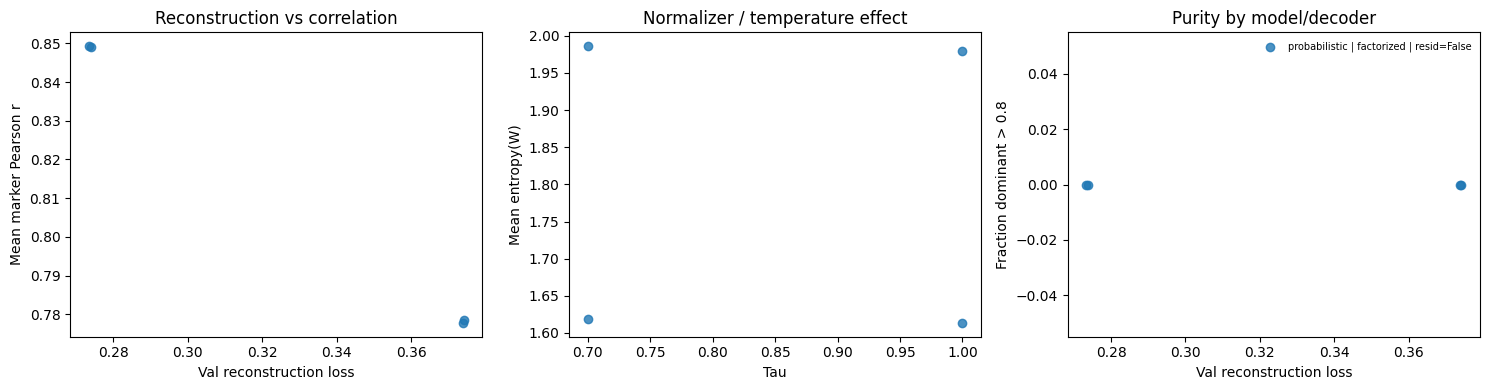

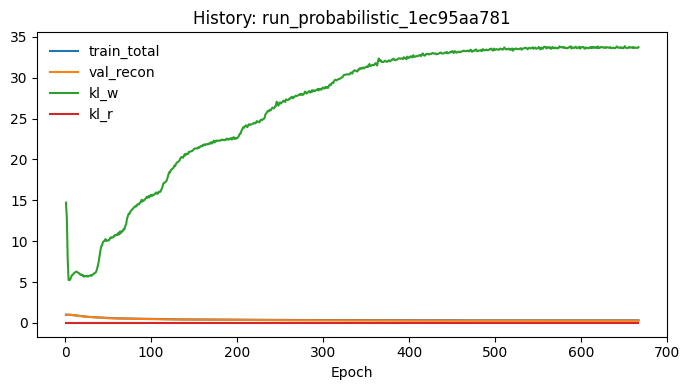

In [20]:
# === Sweep summary plots ===
if 'summary_df' not in globals():
    summary_df = pd.read_csv(OUTPUT_ROOT / "sweep_summary.csv")

display_cols = [
    "run_id", "model_type", "decoder_type", "logit_normalizer", "entmax_alpha", "use_residual_latent", "K", "d", "hidden_dims", "lr", "batch_size",
    "recon_loss_type", "lambda_entropy", "lambda_sep", "lambda_balance", "tau",
    "beta_w", "beta_r", "residual_dim", "val_recon", "mean_marker_corr_val", "mean_entropy_val",
    "dead_archetypes_val", "dominant_frac_gt_0_5_val", "dominant_frac_gt_0_8_val", "run_dir"
]
existing_cols = [c for c in display_cols if c in summary_df.columns]
summary_view = summary_df[existing_cols].sort_values("val_recon", ascending=True)
display(summary_view)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(summary_df["val_recon"], summary_df["mean_marker_corr_val"], alpha=0.8)
axes[0].set_xlabel("Val reconstruction loss")
axes[0].set_ylabel("Mean marker Pearson r")
axes[0].set_title("Reconstruction vs correlation")

axes[1].scatter(summary_df["tau"], summary_df["mean_entropy_val"], alpha=0.8)
axes[1].set_xlabel("Tau")
axes[1].set_ylabel("Mean entropy(W)")
axes[1].set_title("Normalizer / temperature effect")

for label, group in summary_df.groupby(["model_type", "decoder_type", "use_residual_latent"], dropna=False):
    axes[2].scatter(
        group["val_recon"],
        group["dominant_frac_gt_0_8_val"],
        alpha=0.8,
        label=f"{label[0]} | {label[1]} | resid={label[2]}",
    )
axes[2].set_xlabel("Val reconstruction loss")
axes[2].set_ylabel("Fraction dominant > 0.8")
axes[2].set_title("Purity by model/decoder")
axes[2].legend(frameon=False, fontsize=7)

plt.tight_layout()

best_row = summary_df.iloc[0]
print("Best run:")
display(best_row.to_frame().T)

best_history = pd.read_csv(Path(best_row["run_dir"]) / "history.csv")
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(best_history["epoch"], best_history["loss"], label="train_total")
ax.plot(best_history["epoch"], best_history["val_recon"], label="val_recon")
if "kl_w" in best_history.columns:
    ax.plot(best_history["epoch"], best_history["kl_w"], label="kl_w")
if "kl_r" in best_history.columns:
    ax.plot(best_history["epoch"], best_history["kl_r"], label="kl_r")
ax.set_xlabel("Epoch")
ax.set_title(f"History: {best_row['run_id']}")
ax.legend(frameon=False)
plt.tight_layout()
